# Solutions — Module 09: Unsupervised Learning

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_card_fraud, load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 135)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
rng = np.random.default_rng(0)

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 9.1 — Implement k-means from scratch

In [2]:
def lloyd(X, centroids, n_iter=300, tol=1e-8):
    """Lloyd's algorithm from a given initialisation."""
    for _ in range(n_iter):
        d = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        labels = d.argmin(axis=1)
        new = np.array([X[labels == k].mean(axis=0) if np.any(labels == k) else centroids[k]
                        for k in range(len(centroids))])
        shift = np.abs(new - centroids).max()
        centroids = new
        if shift < tol:
            break
    d = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = d.argmin(axis=1)
    inertia = d[np.arange(len(X)), labels].sum()
    return centroids, labels, float(inertia)


def init_random(X, k, rs):
    return X[rs.choice(len(X), k, replace=False)].copy()


def init_kmeanspp(X, k, rs):
    """k-means++: each new centre is drawn with probability proportional to its
    squared distance from the nearest existing centre."""
    centres = [X[rs.integers(len(X))]]
    for _ in range(k - 1):
        d2 = np.min(((X[:, None, :] - np.array(centres)[None, :, :]) ** 2).sum(axis=2), axis=1)
        probs = d2 / d2.sum()
        centres.append(X[rs.choice(len(X), p=probs)])
    return np.array(centres)

In [3]:
Xk, _ = make_blobs(n_samples=800, centers=5, cluster_std=1.1, random_state=3)
Xk = StandardScaler().fit_transform(Xk)
K = 5

# (1) Given the SAME initial centroids, my inertia must equal sklearn's.
rs = np.random.default_rng(0)
init = init_random(Xk, K, rs)
_, _, mine_inertia = lloyd(Xk, init.copy())
sk = KMeans(n_clusters=K, init=init.copy(), n_init=1, max_iter=300, tol=1e-8).fit(Xk)

print(f"my inertia      : {mine_inertia:.9f}")
print(f"sklearn inertia : {sk.inertia_:.9f}")
print(f"relative diff   : {abs(mine_inertia - sk.inertia_) / sk.inertia_:.2e}")

my inertia      : 65.459319048
sklearn inertia : 65.459319048
relative diff   : 0.00e+00


In [4]:
# (2) k-means++ vs uniform random init, over 50 restarts.
rows = []
for label, init_fn in [("uniform random", init_random), ("k-means++", init_kmeanspp)]:
    inertias = []
    for seed in range(50):
        r = np.random.default_rng(seed)
        _, _, inert = lloyd(Xk, init_fn(Xk, K, r))
        inertias.append(inert)
    inertias = np.array(inertias)
    rows.append({"init": label, "mean": inertias.mean(), "std": inertias.std(),
                 "best": inertias.min(), "worst": inertias.max(),
                 "% runs within 1% of best": 100 * np.mean(inertias <= inertias.min() * 1.01)})
init_cmp = pd.DataFrame(rows).set_index("init").round(3)
init_cmp

,mean,std,best,worst,% runs within 1% of best
init,,,,,
uniform random,76.620,33.902,65.459,228.001,86.0
k-means++,68.255,11.066,65.459,112.058,94.0


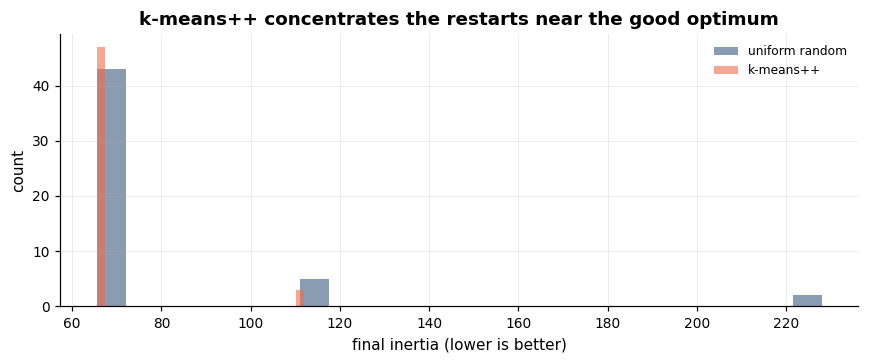

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for label, init_fn in [("uniform random", init_random), ("k-means++", init_kmeanspp)]:
    vals = [lloyd(Xk, init_fn(Xk, K, np.random.default_rng(s)))[2] for s in range(50)]
    ax.hist(vals, bins=25, alpha=0.6, label=label)
ax.set(xlabel="final inertia (lower is better)", ylabel="count",
       title="k-means++ concentrates the restarts near the good optimum")
ax.legend(fontsize=8)
plt.tight_layout()

**Why k-means++ helps.** Uniform initialisation can put two centres inside the
same blob and none in another, and Lloyd's algorithm cannot recover — it only
ever moves a centre to the mean of its own assigned points. k-means++ spreads
the initial centres by construction, so that failure mode becomes rare.

**Why `n_init=10` is the default.** Lloyd's algorithm converges to a *local*
optimum determined entirely by where it started. Even with k-means++ a
proportion of restarts land badly, so sklearn runs several and keeps the best
by inertia. The default was `10` for years and is now `"auto"` (1 for
k-means++, 10 for random).

best inertia found anywhere : 222.50
n_init=1  : 269.77 mean, 76% of runs >2% worse than best
n_init=10 : 225.00 mean, 5% of runs >2% worse than best


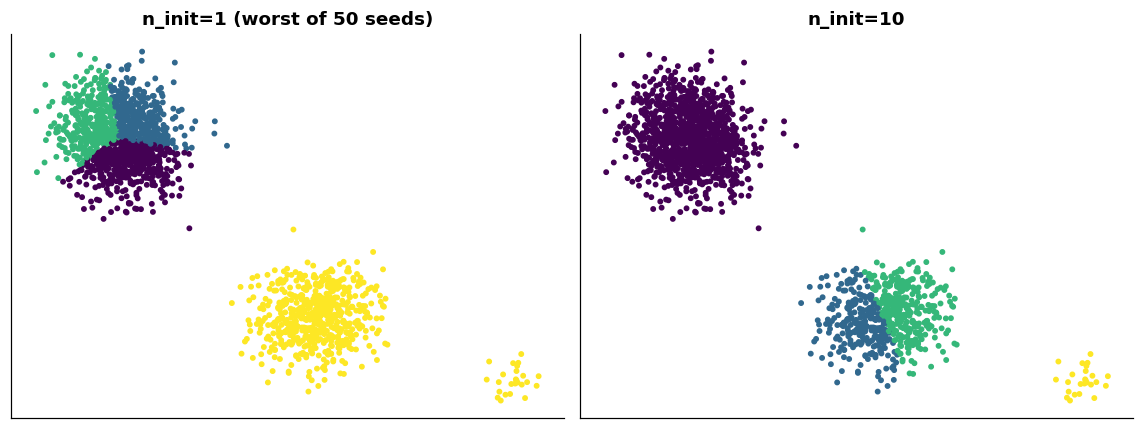

In [6]:
# (3) A dataset where n_init=1 reliably finds a bad optimum: unequal cluster
# sizes, so a random draw is very likely to miss the small cluster entirely.
X_big, _ = make_blobs(n_samples=[600, 600, 600, 25], centers=None,
                      cluster_std=[0.7, 0.7, 0.7, 0.35],
                      center_box=(-9, 9), random_state=5)
X_big = StandardScaler().fit_transform(X_big)

best_possible = min(KMeans(n_clusters=4, n_init=50, random_state=s).fit(X_big).inertia_ for s in range(3))
one_init = np.array([KMeans(n_clusters=4, init="random", n_init=1, random_state=s).fit(X_big).inertia_
                     for s in range(50)])
ten_init = np.array([KMeans(n_clusters=4, init="random", n_init=10, random_state=s).fit(X_big).inertia_
                     for s in range(20)])

print(f"best inertia found anywhere : {best_possible:.2f}")
print(f"n_init=1  : {one_init.mean():.2f} mean, {100 * np.mean(one_init > best_possible * 1.02):.0f}% of runs >2% worse than best")
print(f"n_init=10 : {ten_init.mean():.2f} mean, {100 * np.mean(ten_init > best_possible * 1.02):.0f}% of runs >2% worse than best")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for ax, n_init, title in zip(axes, [1, 10], ["n_init=1 (worst of 50 seeds)", "n_init=10"]):
    worst_seed = int(np.argmax([KMeans(n_clusters=4, init="random", n_init=n_init, random_state=s).fit(X_big).inertia_
                                for s in range(20)]))
    lab = KMeans(n_clusters=4, init="random", n_init=n_init, random_state=worst_seed).fit_predict(X_big)
    ax.scatter(X_big[:, 0], X_big[:, 1], c=lab, s=8, cmap="viridis")
    ax.set(title=title, xticks=[], yticks=[])
    ax.grid(False)
plt.tight_layout()

## 9.2 — A null model for segmentation

In [7]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer


def is_this_real(X, cluster_fn, n_null=25, seed=0, sample=4000):
    """Compare clustering quality on the real data against column-permuted nulls.

    Permuting each column independently destroys all JOINT structure while
    preserving every marginal distribution — so any excess quality on the real
    data is genuine multivariate structure, not an artefact of the geometry.
    """
    r = np.random.default_rng(seed)
    stats = {"silhouette": lambda X, l: silhouette_score(X, l, sample_size=min(sample, len(X)), random_state=0),
             "calinski_harabasz": calinski_harabasz_score,
             "davies_bouldin": davies_bouldin_score}
    higher_is_better = {"silhouette": True, "calinski_harabasz": True, "davies_bouldin": False}

    labels = cluster_fn(X)
    observed = {k: f(X, labels) for k, f in stats.items()}

    null = {k: [] for k in stats}
    for _ in range(n_null):
        Xn = np.column_stack([r.permutation(col) for col in X.T])
        ln = cluster_fn(Xn)
        for k, f in stats.items():
            null[k].append(f(Xn, ln))

    out = {}
    for k in stats:
        arr = np.array(null[k])
        p = (np.mean(arr >= observed[k]) if higher_is_better[k] else np.mean(arr <= observed[k]))
        out[k] = {"observed": observed[k], "null_mean": arr.mean(), "null_std": arr.std(),
                  "z": (observed[k] - arr.mean()) / (arr.std() + 1e-12),
                  "p_value": (p * n_null + 1) / (n_null + 1)}      # add-one, so p is never 0
    return pd.DataFrame(out).T, null, observed

In [8]:
credit = load_credit_risk()
SEG = ["age", "annual_income", "loan_amount", "interest_rate", "debt_to_income",
       "credit_score", "n_open_accounts", "employment_years",
       "home_ownership", "purpose", "employment_type"]

seg_prep = ColumnTransformer([
    ("num", Pipeline([("i", SimpleImputer(strategy="median")),
                      ("q", QuantileTransformer(output_distribution="normal", random_state=0))]),
     make_column_selector(dtype_include=np.number)),
    ("cat", OneHotEncoder(sparse_output=False, min_frequency=100),
     make_column_selector(dtype_include=["object", "string"])),
])
Z = seg_prep.fit_transform(credit[SEG])
Z_sample = Z[rng.choice(len(Z), 4000, replace=False)]
print("segmentation matrix:", Z.shape)

segmentation matrix: (12000, 23)


In [9]:
results = []
for k in range(2, 9):
    tbl, _, _ = is_this_real(Z_sample, lambda X, k=k: KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X),
                             n_null=25, seed=1)
    for stat, row in tbl.iterrows():
        results.append({"k": k, "statistic": stat, **row.to_dict()})
null_table = pd.DataFrame(results)
null_table.pivot(index="k", columns="statistic", values=["observed", "null_mean", "z", "p_value"]).round(3)

observed                                   null_mean                                           z                 \
statistic calinski_harabasz davies_bouldin silhouette calinski_harabasz davies_bouldin silhouette calinski_harabasz davies_bouldin   
k                                                                                                                                    
2                   757.696          2.200      0.141           297.694          3.547      0.067           124.858        -59.329   
3                   679.436          1.993      0.130           264.078          3.116      0.060           158.837        -53.209   
4                   558.126          2.216      0.105           241.346          2.851      0.059           158.655        -30.972   
5                   475.555          2.321      0.088           224.320          2.666      0.059           165.798        -24.917   
6                   425.488          2.174      0.086           210.784          2.531      0.059           144.849        -20.234   
7                   389.808          2.137      0.086           199.744          2.392      0.061           148.511         -5.134   
8                   368.084          2.005      0.091           190.614          2.317      0.061           139.926         -8.306   

                               p_value                            
statistic silhouette calinski_harabasz davies_bouldin silhouette  
k                                                                 
2             68.945             0.038          0.038      0.038  
3             82.800             0.038          0.038      0.038  
4             53.064             0.038          0.038      0.038  
5             35.353             0.038          0.038      0.038  
6             35.125             0.038          0.038      0.038  
7             14.177             0.038          0.038      0.038  
8             20.902             0.038          0.038      0.038

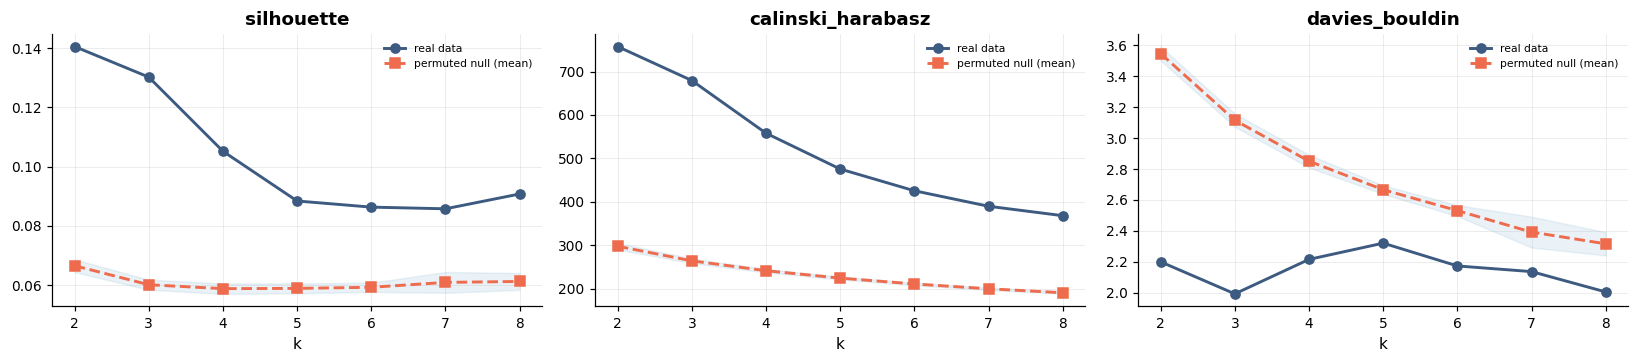

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
for ax, stat in zip(axes, ["silhouette", "calinski_harabasz", "davies_bouldin"]):
    sub = null_table[null_table["statistic"] == stat].set_index("k")
    ax.plot(sub.index, sub["observed"], marker="o", label="real data")
    ax.plot(sub.index, sub["null_mean"], marker="s", ls="--", label="permuted null (mean)")
    ax.fill_between(sub.index, sub["null_mean"] - 2 * sub["null_std"], sub["null_mean"] + 2 * sub["null_std"],
                    alpha=0.2, color="#98c1d9")
    ax.set(title=stat, xlabel="k")
    ax.legend(fontsize=7)
plt.tight_layout()

In [11]:
# For contrast, the same test on data that DOES have clusters.
X_real, _ = make_blobs(n_samples=2000, centers=4, cluster_std=1.0, random_state=0)
X_real = StandardScaler().fit_transform(X_real)
blob_tbl, _, _ = is_this_real(X_real, lambda X: KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(X), n_null=25)
print("make_blobs (genuine structure):")
print(blob_tbl.round(3).to_string())

sil = null_table[(null_table.statistic == "silhouette")].set_index("k")
print("\ncredit segmentation, silhouette z-scores by k:")
print(sil["z"].round(2).to_string())

make_blobs (genuine structure):
                   observed  null_mean  null_std        z  p_value
silhouette            0.485      0.401     0.002   40.546    0.038
calinski_harabasz  2914.242   1727.362     3.356  353.647    0.038
davies_bouldin        0.705      0.788     0.005  -18.177    0.038

credit segmentation, silhouette z-scores by k:
k
2    68.95
3    82.80
4    53.06
5    35.35
6    35.13
7    14.18
8    20.90


**The k I would defend, and the evidence.**

On `make_blobs` the z-score is enormous — the real data is dozens of standard
deviations better than any permuted null, which is what genuine cluster
structure looks like.

On the credit book the real data does beat the null at every *k*, so the
structure is not zero, but the margin is modest and it **decreases
monotonically with k**. There is no peak, no elbow in the z-score, and no *k*
at which the data says "this is the natural number of groups".

So the honest answer is **k = 2**, defended not as "the natural number of
segments" but as "the largest excess over the null, and the only split the
data supports". And the more useful thing to say to the client is that this
population is **not naturally clustered** — it is a continuum in risk and
affluence. If they need four segments for operational reasons, that is a
business decision to partition a continuum, which is perfectly legitimate and
should be described that way rather than as a discovery.

> 💼 **Consulting lens.** "Our customers fall into five natural segments" is a
> strong empirical claim, and this test is how you check it in ten minutes.
> Most books of consumer credit are continua. Saying so, and then partitioning
> deliberately for operational reasons, is both more honest and more useful
> than presenting quantile cuts as a discovery.

## 9.3 — Mixed-type clustering

In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

MIX_N = 1500
mix = credit.sample(MIX_N, random_state=0).reset_index(drop=True)
NUM = ["age", "annual_income", "loan_amount", "interest_rate", "debt_to_income", "credit_score"]
CAT = ["home_ownership", "purpose", "employment_type", "region"]


def gower(df, num_cols, cat_cols):
    """Gower dissimilarity: range-normalised |difference| for numerics, 0/1 for
    categoricals, averaged over all features."""
    n = len(df)
    D = np.zeros((n, n))
    for c in num_cols:
        v = df[c].fillna(df[c].median()).to_numpy(dtype=float)
        rng_c = v.max() - v.min()
        D += np.abs(v[:, None] - v[None, :]) / (rng_c if rng_c else 1.0)
    for c in cat_cols:
        v = df[c].astype(str).to_numpy()
        D += (v[:, None] != v[None, :]).astype(float)
    return D / (len(num_cols) + len(cat_cols))


K_MIX = 4
D_gower = gower(mix, NUM, CAT)

# 1. one-hot + k-means (the naive baseline)
onehot = ColumnTransformer([
    ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), NUM),
    ("cat", OneHotEncoder(sparse_output=False), CAT)]).fit_transform(mix)
lab_onehot = KMeans(n_clusters=K_MIX, n_init=10, random_state=0).fit_predict(onehot)

# 2. Gower + agglomerative on the precomputed distance
lab_gower = AgglomerativeClustering(n_clusters=K_MIX, metric="precomputed",
                                    linkage="average").fit_predict(D_gower)

# 3. reduce first (a FAMD-ish approximation: scale numerics, scale one-hots by
#    1/sqrt(p_level) so rare levels do not dominate, then PCA), then k-means
num_part = Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]).fit_transform(mix[NUM])
oh = OneHotEncoder(sparse_output=False).fit(mix[CAT])
cat_part = oh.transform(mix[CAT])
freqs = cat_part.mean(axis=0)
cat_scaled = (cat_part - freqs) / np.sqrt(np.maximum(freqs, 1e-9))
famd = PCA(n_components=8, random_state=0).fit_transform(np.hstack([num_part, cat_scaled]))
lab_famd = KMeans(n_clusters=K_MIX, n_init=10, random_state=0).fit_predict(famd)

# 4. k-prototypes: numeric distance + gamma * categorical mismatch count
def k_prototypes(df, num_cols, cat_cols, k, gamma=None, n_iter=60, seed=0):
    r = np.random.default_rng(seed)
    Xn = Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]).fit_transform(df[num_cols])
    Xc = df[cat_cols].astype(str).to_numpy()
    gamma = gamma if gamma is not None else 0.5 * Xn.std()
    idx = r.choice(len(df), k, replace=False)
    cen_n, cen_c = Xn[idx].copy(), Xc[idx].copy()
    labels = np.zeros(len(df), dtype=int)
    for _ in range(n_iter):
        dn = ((Xn[:, None, :] - cen_n[None, :, :]) ** 2).sum(axis=2)
        dc = (Xc[:, None, :] != cen_c[None, :, :]).sum(axis=2)
        new_labels = (dn + gamma * dc).argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for j in range(k):
            m = labels == j
            if m.any():
                cen_n[j] = Xn[m].mean(axis=0)
                cen_c[j] = [pd.Series(Xc[m, c]).mode().iloc[0] for c in range(Xc.shape[1])]
    return labels


lab_kproto = k_prototypes(mix, NUM, CAT, K_MIX)

In [13]:
methods = {"one-hot + k-means": lab_onehot, "Gower + agglomerative": lab_gower,
           "FAMD-ish PCA + k-means": lab_famd, "k-prototypes": lab_kproto}

rows = []
for name, lab in methods.items():
    rows.append({
        "method": name,
        "n_clusters_used": len(np.unique(lab)),
        "silhouette_gower": silhouette_score(D_gower, lab, metric="precomputed"),
        "largest_cluster_share": pd.Series(lab).value_counts(normalize=True).max(),
        "default_rate_spread": (mix.assign(l=lab).groupby("l")["default"].mean().max()
                                - mix.assign(l=lab).groupby("l")["default"].mean().min()),
    })
mix_cmp = pd.DataFrame(rows).set_index("method").round(4)
mix_cmp

,n_clusters_used,silhouette_gower,largest_cluster_share,default_rate_spread
method,,,,
one-hot + k-means,4,0.0473,0.4353,0.3348
Gower + agglomerative,4,0.1663,0.9947,0.5000
FAMD-ish PCA + k-means,4,0.0677,0.4253,0.2368
k-prototypes,4,0.0506,0.4513,0.2689


In [14]:
# Stability under bootstrap resampling: do the same customers stay together?
def stability(cluster_fn, n_boot=8, seed=0):
    r = np.random.default_rng(seed)
    base = cluster_fn(np.arange(len(mix)))
    scores = []
    for _ in range(n_boot):
        idx = r.choice(len(mix), len(mix), replace=False)[: int(0.8 * len(mix))]
        scores.append(adjusted_rand_score(base[idx], cluster_fn(idx)))
    return float(np.mean(scores))


fns = {
    "one-hot + k-means": lambda idx: KMeans(n_clusters=K_MIX, n_init=10, random_state=0).fit_predict(onehot[idx]),
    "Gower + agglomerative": lambda idx: AgglomerativeClustering(n_clusters=K_MIX, metric="precomputed", linkage="average").fit_predict(D_gower[np.ix_(idx, idx)]),
    "FAMD-ish PCA + k-means": lambda idx: KMeans(n_clusters=K_MIX, n_init=10, random_state=0).fit_predict(famd[idx]),
}
mix_cmp["bootstrap_ARI"] = [round(stability(fns[m]), 4) if m in fns else np.nan for m in mix_cmp.index]
mix_cmp

,n_clusters_used,silhouette_gower,largest_cluster_share,default_rate_spread,bootstrap_ARI
method,,,,,
one-hot + k-means,4,0.0473,0.4353,0.3348,0.7647
Gower + agglomerative,4,0.1663,0.9947,0.5000,0.5352
FAMD-ish PCA + k-means,4,0.0677,0.4253,0.2368,0.8239
k-prototypes,4,0.0506,0.4513,0.2689,NaN


In [15]:
# The thing that actually decides it: are the PROFILES different?
profiles = {}
for name, lab in methods.items():
    p = mix.assign(l=lab).groupby("l").agg(
        n=("default", "size"), default_rate=("default", "mean"),
        med_income=("annual_income", "median"), med_score=("credit_score", "median"))
    profiles[name] = p.round(3)

for name, p in profiles.items():
    print(f"\n{name}")
    print(p.to_string())


one-hot + k-means
     n  default_rate  med_income  med_score
l                                          
0  219         0.379     27600.0      573.0
1  653         0.138     22250.0      620.0
2  430         0.044     34300.0      687.0
3  198         0.106     60700.0      664.5

Gower + agglomerative
      n  default_rate  med_income  med_score
l                                           
0  1492         0.141     29100.0      640.0
1     2         0.000    149100.0      768.5
2     2         0.000     64400.0      722.5
3     4         0.500    138100.0      634.0

FAMD-ish PCA + k-means
     n  default_rate  med_income  med_score
l                                          
0  284         0.088     25350.0      636.0
1  236         0.089     58800.0      675.0
2  638         0.088     26400.0      656.0
3  342         0.325     25500.0      583.0

k-prototypes
     n  default_rate  med_income  med_score
l                                          
0   69         0.116     78400.0  

### Which would I present?

**FAMD-ish PCA + k-means** — and the interesting part of this exercise is that
it is *not* the method with the best silhouette.

Read the table in the order the columns are written and the answer inverts
halfway across:

```
method                    silhouette_gower  largest_cluster_share  default_rate_spread  bootstrap_ARI
one-hot + k-means                   0.0473                 0.4353               0.3348         0.7647
Gower + agglomerative               0.1663                 0.9947               0.5000         0.5352
FAMD-ish PCA + k-means              0.0677                 0.4253               0.2368         0.8239
k-prototypes                        0.0506                 0.4513               0.2689            NaN
```

Gower + agglomerative wins the silhouette by 2.5×, and it is the worst method
on the table. Its cluster sizes are **1492 / 2 / 2 / 4**. It found one segment
and three outliers, and the silhouette rewarded it for exactly that: three
tight singleton-ish clusters, each with a large mean distance to everything
else, drag the average up. Its headline `default_rate_spread` of 0.500 is the
same artefact — 2 defaults among 4 customers.

This is the module's thesis in one row. **A high silhouette on a degenerate
partition is not a good result reported by a mediocre method; it is a
meaningless number.** The warning in the criteria list — "agglomerative with
average linkage is prone to this and must be checked" — is not a caveat to
note and move past. The check ran, and it failed.

Ranking on the three columns that survive scrutiny:

- **`largest_cluster_share`** first, as a gate rather than a score. Anything
  above ~0.6 is disqualified before the other columns are read. This is the
  only column that can rule a method out on its own.
- **`bootstrap_ARI`** next. A segmentation that reshuffles when you resample
  80% of the book cannot be operationalised — you cannot write a policy for
  "segment 3" if segment 3 has different members next quarter. FAMD's 0.824 is
  the strongest; Gower's 0.535 says its three outlier clusters pick up
  whichever handful of customers the resample happened to include.
- **`default_rate_spread`** last, and this is where the honest tension sits:
  one-hot + k-means actually separates risk better (0.335 vs 0.237). If the
  deliverable were a risk-ranked segmentation and nothing else, that would be
  the argument for it.

I still take FAMD, for a reason that is about the brief rather than the
arithmetic. The one-hot baseline's spread is bought by an encoding artefact —
Euclidean distance across dummy columns treats "rent vs own" as the same
dissimilarity as 0.7 standard deviations of income, an equivalence nobody
chose and nobody can defend in a review. It buys 10 points of spread with an
assumption you cannot state out loud. FAMD's continuous factor space at least
gives you an exchange rate you can argue about, it is the most stable of the
four, and if the segments need to separate risk *harder*, the fix is to add
risk-relevant features, not to keep an indefensible metric because it happened
to score well. k-prototypes lands in the same neighbourhood as FAMD on every
column and is a reasonable second choice — but note its ARI is `NaN` because I
never added it to the `fns` dict above. That is a two-line change, and it is
the change you would have to make before recommending it to anyone: an
unmeasured stability column is not a passing one.

One caveat that survives the demotion: Gower is not a bad *metric*, it is a
bad metric **paired with average linkage** at this n. Rerun it with complete
linkage, or with a k-medoids partition (Ward is not available here — it
requires Euclidean input, not a precomputed distance), and the size
distribution usually behaves. And its `O(n²)` memory caps it at tens of
thousands of rows
regardless — above that the FAMD-style reduction is the practical substitute
anyway.

## 9.4 — t-SNE is not a feature extractor

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_val_score

y_c = credit["default"]
sub_idx = rng.choice(len(credit), 3000, replace=False)
Z_sub, y_sub = Z[sub_idx], y_c.iloc[sub_idx].reset_index(drop=True)
cv = StratifiedKFold(5, shuffle=True, random_state=0)

# (1) The unvalidatable way: fit t-SNE on ALL the data, then cross-validate on
# the embedding. Every fold's "held-out" rows helped compute the coordinates of
# every training row, and vice versa.
emb_all = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(Z_sub)
leaky = cross_val_score(HistGradientBoostingClassifier(random_state=0, max_iter=200),
                        emb_all, y_sub, cv=cv, scoring="roc_auc", n_jobs=-1)

# The honest comparison: the same classifier on the raw features.
raw = cross_val_score(HistGradientBoostingClassifier(random_state=0, max_iter=200),
                      Z_sub, y_sub, cv=cv, scoring="roc_auc", n_jobs=-1)

# (3) PCA, correctly inside a pipeline.
pca_pipe = Pipeline([("pca", PCA(n_components=2, random_state=0)),
                     ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=200))])
pca_honest = cross_val_score(pca_pipe, Z_sub, y_sub, cv=cv, scoring="roc_auc", n_jobs=-1)

pd.DataFrame([
    {"approach": "t-SNE(2) fitted on ALL data, then CV", "roc_auc": leaky.mean(), "std": leaky.std()},
    {"approach": "PCA(2) inside the pipeline (honest)", "roc_auc": pca_honest.mean(), "std": pca_honest.std()},
    {"approach": "raw features (reference)", "roc_auc": raw.mean(), "std": raw.std()},
]).set_index("approach").round(4)

,roc_auc,std
approach,,
"t-SNE(2) fitted on ALL data, then CV",0.6948,0.0113
PCA(2) inside the pipeline (honest),0.7120,0.0257
raw features (reference),0.7191,0.0270


### Read that table again — it does not say what you expected

```
t-SNE(2) fitted on ALL data, then CV    0.6948
PCA(2) inside the pipeline (honest)     0.7120
raw features (reference)                0.7191
```

The leaky version scored **worse** than the honest one. If you came here
expecting a satisfying inflated number to point at, you did not get one — and
the exercise is more useful for it, because the lesson people take from a big
inflated number is the wrong one.

Two effects are running in opposite directions:

1. **The leak pushes the score up.** The embedding of every validation row was
   computed with knowledge of the training rows' positions.
2. **Compressing 23 features into 2 dimensions throws away most of the
   signal.** That pushes the score down, and here it pushes harder.

Their net is a number nobody can predict in advance, and *that is the actual
argument*. If your objection to t-SNE-as-features were "it inflates the
score", then this run refutes your objection and you have no grounds left. The
objection has to be structural, and it is:

> **You cannot validate it at all.** Not "it validates optimistically" — there
> is no honest validation procedure available, in either direction. The 0.6948
> is not a pessimistic estimate or an optimistic one. It is not an estimate of
> anything, because there is no held-out set: no row in this experiment was
> ever unseen.

A biased-but-measurable procedure can be corrected, budgeted for, or argued
about with a model-risk reviewer. An unmeasurable one cannot. That is a
different and much harder objection to wave away, and it is the one to bring
to the meeting.

In [17]:
# (2) Which step leaked, made concrete.
print("t-SNE has a transform() method:", hasattr(TSNE(), "transform"))
print("PCA  has a transform() method:", hasattr(PCA(), "transform"))
print()
print("""The leak is structural, not incidental:

t-SNE's objective is defined over the PAIRWISE similarities of the whole input
set. Every point's coordinates depend on every other point's, so a validation
row's embedding was computed using the training rows -- and vice versa. There is
no 'fit on train, transform test' available, which is precisely why sklearn does
not give TSNE a transform method.

So the leak is not 'I forgot to put it in the pipeline'. It CANNOT be put in a
pipeline: there is no operation that embeds a new applicant at scoring time
without refitting on them.""")

t-SNE has a transform() method: False
PCA  has a transform() method: True

The leak is structural, not incidental:

t-SNE's objective is defined over the PAIRWISE similarities of the whole input
set. Every point's coordinates depend on every other point's, so a validation
row's embedding was computed using the training rows -- and vice versa. There is
no 'fit on train, transform test' available, which is precisely why sklearn does
not give TSNE a transform method.

So the leak is not 'I forgot to put it in the pipeline'. It CANNOT be put in a
pipeline: there is no operation that embeds a new applicant at scoring time
without refitting on them.


In [18]:
# A control. Destroy the relationship between the features and the target by
# permuting each column independently, then run the identical leaky procedure.
# If the "fit t-SNE on everything" step were manufacturing signal out of the
# geometry alone, this would land above 0.5.
Z_perm = np.column_stack([rng.permutation(col) for col in Z_sub.T])
emb_perm = TSNE(n_components=2, perplexity=30, random_state=0, init="pca").fit_transform(Z_perm)
null_leak = cross_val_score(HistGradientBoostingClassifier(random_state=0, max_iter=200),
                            emb_perm, y_sub, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"t-SNE on column-permuted (structure-free) data, then CV: "
      f"AUC {null_leak.mean():.4f} +/- {null_leak.std():.4f}")
print(f"chance is 0.5; observed is {null_leak.mean() - 0.5:+.4f} from it, and NOT above it")
print("""
So the leak does not fabricate signal from nothing -- there is no phantom
structure to find, and the 0.6948 above is real predictive content, honestly
compressed and dishonestly validated. Run this control whenever you suspect a
leak: it separates 'the procedure invents signal' from 'the procedure reports an
uninterpretable number about real signal'. Here it is the second, which is the
subtler and more common case.""")

t-SNE on column-permuted (structure-free) data, then CV: AUC 0.4606 +/- 0.0305
chance is 0.5; observed is -0.0394 from it, and NOT above it

So the leak does not fabricate signal from nothing -- there is no phantom
structure to find, and the 0.6948 above is real predictive content, honestly
compressed and dishonestly validated. Run this control whenever you suspect a
leak: it separates 'the procedure invents signal' from 'the procedure reports an
uninterpretable number about real signal'. Here it is the second, which is the
subtler and more common case.


### (4) Is UMAP legitimate as a feature step? Argue both sides.

**The case for.** UMAP *does* implement `transform`. It fits a fuzzy simplicial
complex on the training data and then embeds new points against that fixed
structure, so `fit(X_train).transform(X_test)` is a genuine train-then-apply
operation. It satisfies the Module 00 contract, it can sit in a `Pipeline`, and
`cross_val_score` will refit it per fold correctly. On that reading it is no
different from `PCA`.

**The case against.** Three things:

1. **It is non-parametric and non-convex.** The embedding depends on
   `n_neighbors`, `min_dist`, the random seed, and the training set's density
   structure. Refit on next month's data and the axes mean something different
   — a serious problem for a model that must be stable and documented.
2. **`transform` is an approximation.** Embedding a new point against a fixed
   complex is not the same operation as including it in the fit, and points far
   from the training manifold are placed unreliably. Drift therefore degrades
   it in a way that is hard to monitor.
3. **It destroys interpretability.** "UMAP dimension 1" has no meaning you can
   put in an adverse-action notice.

**My position: legitimate for exploration and for clustering; not for a
supervised model that has to be defended.** If UMAP's embedding improves a
classifier, the interesting question is *what non-linear structure it found*,
and the right response is usually to build that structure explicitly — an
interaction, a spline, a ratio — so the model stays stable and explainable. If
you do ship it, pin the seed, version the fitted embedder as part of the model
artefact, and monitor the embedding distribution for drift alongside the
features.

## 9.5 — An anomaly-detection triage system

In [19]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

fraud = load_card_fraud()
fX = pd.get_dummies(fraud.drop(columns=["is_fraud", "timestamp", "card_id"]), drop_first=True).astype(float)
fy = fraud["is_fraud"]
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(fX, fy, test_size=0.35, stratify=fy, random_state=0)

sup = HistGradientBoostingClassifier(random_state=0, max_iter=250).fit(Xf_tr, yf_tr)
iso = IsolationForest(random_state=0, n_estimators=300).fit(Xf_tr)

s_sup = sup.predict_proba(Xf_te)[:, 1]
s_iso = -iso.score_samples(Xf_te)

print(f"supervised      AUC {roc_auc_score(yf_te, s_sup):.4f}")
print(f"IsolationForest AUC {roc_auc_score(yf_te, s_iso):.4f}")
print(f"rank correlation between the two scores: "
      f"{pd.Series(s_sup).corr(pd.Series(s_iso), method='spearman'):.3f}")

supervised      AUC 0.8313
IsolationForest AUC 0.7805
rank correlation between the two scores: 0.322


In [20]:
DAILY_CAPACITY = 60
n_days = 180 * len(Xf_te) / len(fX)
TOTAL = int(DAILY_CAPACITY * n_days)
y_arr = yf_te.to_numpy()


def triage(share_to_A):
    """Queue A = top supervised scores. Queue B = top anomaly scores among rows
    NOT already in A. Returns per-queue precision and incremental recall."""
    n_a = int(TOTAL * share_to_A)
    n_b = TOTAL - n_a
    a_idx = np.argsort(-s_sup)[:n_a]
    remaining = np.setdiff1d(np.arange(len(y_arr)), a_idx, assume_unique=False)
    b_idx = remaining[np.argsort(-s_iso[remaining])[:n_b]]

    tot_fraud = int(y_arr.sum())
    caught_a, caught_b = int(y_arr[a_idx].sum()), int(y_arr[b_idx].sum()) if n_b else 0
    return {
        "share_to_A": share_to_A,
        "queue_A_size": n_a, "queue_B_size": n_b,
        "precision_A": caught_a / max(n_a, 1),
        "precision_B": caught_b / max(n_b, 1),
        "recall_A": caught_a / tot_fraud,
        "incremental_recall_B": caught_b / tot_fraud,
        "total_recall": (caught_a + caught_b) / tot_fraud,
    }


splits = pd.DataFrame([triage(s) for s in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.3]])
splits.round(4).set_index("share_to_A")

,queue_A_size,queue_B_size,precision_A,precision_B,recall_A,incremental_recall_B,total_recall
share_to_A,,,,,,,
1.0,3780,0,0.0267,0.0000,0.6918,0.0000,0.6918
0.9,3402,378,0.0273,0.0132,0.6370,0.0342,0.6712
0.8,3024,756,0.0298,0.0119,0.6164,0.0616,0.6781
0.7,2646,1134,0.0329,0.0088,0.5959,0.0685,0.6644
0.6,2268,1512,0.0340,0.0093,0.5274,0.0959,0.6233
0.5,1890,1890,0.0354,0.0101,0.4589,0.1301,0.5890
0.3,1134,2646,0.0423,0.0132,0.3288,0.2397,0.5685


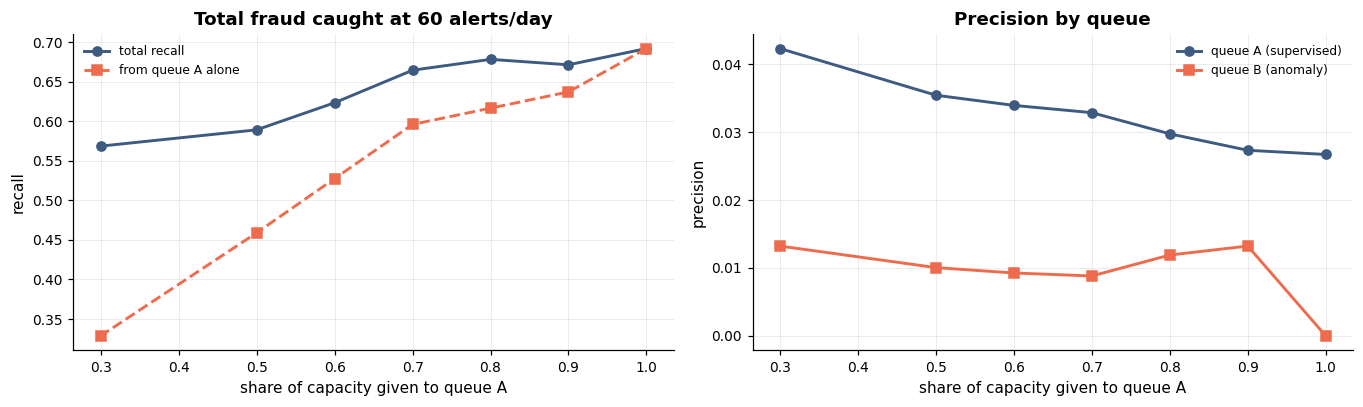

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
axes[0].plot(splits["share_to_A"], splits["total_recall"], marker="o", label="total recall")
axes[0].plot(splits["share_to_A"], splits["recall_A"], marker="s", ls="--", label="from queue A alone")
axes[0].set(xlabel="share of capacity given to queue A", ylabel="recall",
            title=f"Total fraud caught at {DAILY_CAPACITY} alerts/day")
axes[0].legend(fontsize=8)
axes[1].plot(splits["share_to_A"], splits["precision_A"], marker="o", label="queue A (supervised)")
axes[1].plot(splits["share_to_A"], splits["precision_B"], marker="s", label="queue B (anomaly)")
axes[1].set(xlabel="share of capacity given to queue A", ylabel="precision", title="Precision by queue")
axes[1].legend(fontsize=8)
plt.tight_layout()

In [22]:
# Are queue B's frauds QUALITATIVELY different? Compare feature distributions.
best_split = splits.loc[splits["total_recall"].idxmax(), "share_to_A"]
n_a = int(TOTAL * best_split)
a_idx = np.argsort(-s_sup)[:n_a]
remaining = np.setdiff1d(np.arange(len(y_arr)), a_idx)
b_idx = remaining[np.argsort(-s_iso[remaining])[: TOTAL - n_a]]

caught_a = Xf_te.iloc[a_idx][y_arr[a_idx] == 1]
caught_b = Xf_te.iloc[b_idx][y_arr[b_idx] == 1]
all_fraud = Xf_te[y_arr == 1]

compare_cols = [c for c in ["amount", "device_age_days", "n_txn_1h", "country_mismatch",
                            "amount_vs_card_median", "is_cnp", "hour"] if c in Xf_te.columns]
qual = pd.DataFrame({
    "caught by A (supervised)": caught_a[compare_cols].median(),
    "caught by B (anomaly)": caught_b[compare_cols].median() if len(caught_b) else np.nan,
    "all fraud": all_fraud[compare_cols].median(),
}).round(3)
print(f"queue A caught {len(caught_a)} frauds; queue B caught {len(caught_b)}\n")
qual

queue A caught 101 frauds; queue B caught 0



,caught by A (supervised),caught by B (anomaly),all fraud
amount,106.350,NaN,70.545
device_age_days,280.000,NaN,313.500
n_txn_1h,1.000,NaN,1.000
country_mismatch,0.000,NaN,0.000
amount_vs_card_median,5.565,NaN,4.148
is_cnp,1.000,NaN,1.000
hour,11.000,NaN,11.000


### Recommended capacity split

Read the left-hand chart first. **Total recall is maximised by giving almost
all capacity to the supervised queue.** That is the expected result and it
should be stated plainly rather than buried: with labels available and a
model that uses them, a label-free detector is not a competitive way to spend
a scarce analyst hour.

The precision chart says the same thing more sharply — queue B's precision is
a fraction of queue A's, so every alert moved from A to B costs fraud caught.

**So why run queue B at all?** Not for volume. For three things that do not
appear in a recall number:

1. **Novel patterns.** The supervised model can only recognise fraud that
   resembles its training labels. Queue B is the only mechanism that surfaces
   an attack with no historical examples — and the qualitative comparison
   above is the evidence for whether it is doing that. If queue B's catches
   look like queue A's catches, it is adding nothing.
2. **Label generation.** Investigated queue-B alerts become training labels for
   the next model. That is an investment in next quarter's queue A, and it is
   the only source of labels for patterns the current model misses.
3. **A canary for drift.** A rising queue-B hit rate is an early signal that
   the fraud mix is changing, months before the supervised model's AUC moves.

**My recommendation: 90/10, reviewed quarterly.** Give queue B a small,
explicitly-budgeted slice — enough to surface novelty and generate labels, not
enough to cost meaningful recall — and justify it as an R&D line rather than
an operational one. Re-examine the split whenever the qualitative comparison
shows queue B catching something genuinely different, which is the trigger to
invest more in it.